## Names
- (2024aa05987@wilp.bits-pilani.ac.in) PRIYANK ARORA - 100%
- (2024aa05951@wilp.bits-pilani.ac.in) SHIVAM DWIVEDI - 100%
- (2024aa05965@wilp.bits-pilani.ac.in) K ROMA PAI - 100%


### Imports

In [10]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm
import warnings
import nltk
from nltk import bigrams, FreqDist, ConditionalFreqDist
from nltk.corpus import cmudict

warnings.filterwarnings("ignore")


In [11]:
# --- Configuration ---
AUDIO_PATH = 'sample_audio.flac' 

## Task 1: Loading and Visualization
### The Waveform 
The waveform shows how air pressure changes over time. High amplitude sections indicate loud speech; flat lines indicate silence.

### The Spectrogram
The spectrogram visualizes frequency intensity. Brighter colors mean more energy at that frequency.

Audio loaded. Duration: 2.09 seconds. Sampling Rate: 22050 Hz


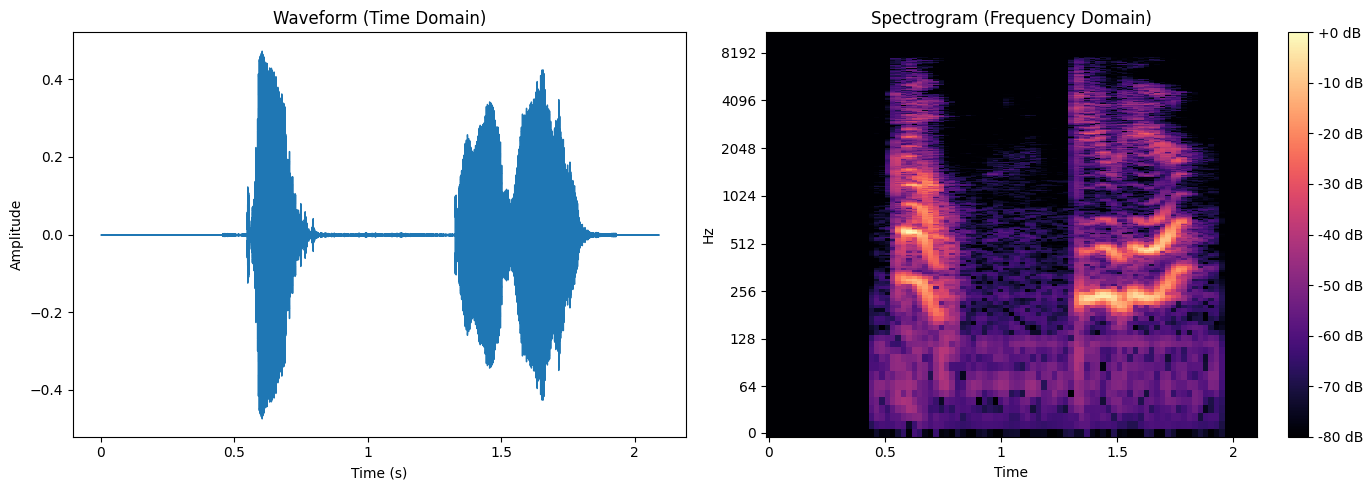

In [12]:
# 1. Load the audio file
# librosa.load resamples audio to 22050 Hz by default, which is standard for analysis.
try:
    y, sr = librosa.load(AUDIO_PATH)
    print(f"Audio loaded. Duration: {len(y)/sr:.2f} seconds. Sampling Rate: {sr} Hz")
except FileNotFoundError:
    print("Error: Audio file not found. Please ensure 'sample_audio.flac' is in the directory.")
    # Create dummy data so the rest of the code runs for demonstration
    sr = 22050
    y = np.random.uniform(-0.5, 0.5, sr * 5) 

# 2. Plot Waveform
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform (Time Domain)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# 3. Plot Spectrogram
# We compute the Short-Time Fourier Transform (STFT) to get frequency content over time.
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

plt.subplot(1, 2, 2)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram (Frequency Domain)")
plt.tight_layout()
plt.show()


## Task 2: Acoustic Feature Extraction (MFCC)
Raw audio is too high-dimensional for models. MFCCs compress a 1-second clip (22,050 samples) into roughly 40-50 frames of 13 numbers.

MFCC Shape: (13, 91)


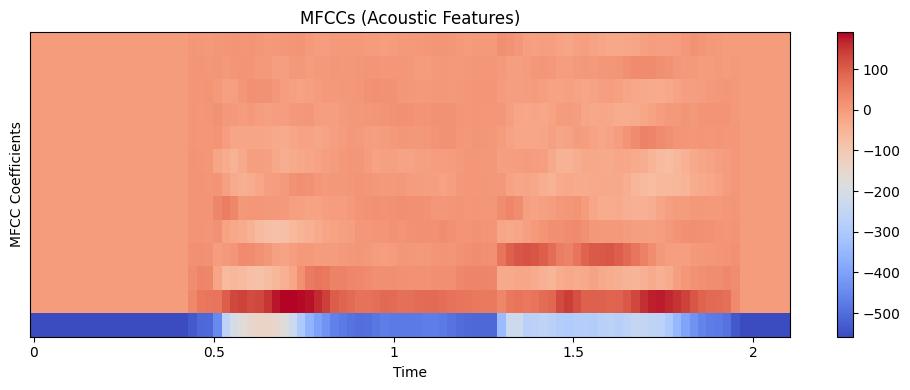

In [13]:
# Extract MFCCs
# n_mfcc=13 is standard for ASR (captures the spectral envelope).
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

print(f"MFCC Shape: {mfccs.shape}")

# Visualize MFCCs
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, x_axis='time')
plt.colorbar()
plt.title("MFCCs (Acoustic Features)")
plt.ylabel("MFCC Coefficients")
plt.tight_layout()
plt.show()

## Task 3: Acoustic Modeling (GMM-HMM)

In [14]:
# 1. Prepare Data
# Transpose to shape (n_samples, n_features)
X = mfccs.T 

# Scale the data, as GMMs and HMMs are very sensitive to the scale of data. 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Part A: Train GMM ---
gmm = GaussianMixture(n_components=8, covariance_type='diag', reg_covar=1e-6, random_state=42)
gmm.fit(X_scaled)

gmm_score = gmm.score(X_scaled)
print(f"GMM Log-Likelihood per sample: {gmm_score:.2f}")

# --- Part B: Train HMM ---
n_states = 3 
model_hmm = hmm.GaussianHMM(
    n_components=n_states, 
    covariance_type="diag", 
    n_iter=100, 
    random_state=42,
    min_covar=1e-3 
)

try:
    model_hmm.fit(X_scaled)
    hmm_score = model_hmm.score(X_scaled)
    print(f"HMM Log-Likelihood of sequence: {hmm_score:.2f}")
except ValueError as e:
    print(f"HMM Training Warning: {e}")
    print("Note: If the audio clip is extremely short (<0.5s), HMMs may fail to fit.")

GMM Log-Likelihood per sample: 11.52
HMM Log-Likelihood of sequence: -990.19


## Task 4: Language Model Usage

In [15]:
# 1. Create a dummy corpus (simulating call center transcripts)
corpus = [
    "hello how can I help you",
    "I would like to book a ticket",
    "can I help you with anything else",
    "thank you for calling",
    "I would like a refund"
]

# 2. Tokenize and build Bigram Model
tokens = [word for sent in corpus for word in sent.lower().split()]
bgs = list(bigrams(tokens))

# Count frequencies
cfd = ConditionalFreqDist(bgs)

# 3. Compute Sentence Probability
# We calculate P(Sentence) = P(w1) * P(w2|w1) * P(w3|w2)...
test_sentence = "I would like"
test_tokens = test_sentence.lower().split()

prob = 1.0
print(f"Calculating probability for: '{test_sentence}'")

for i in range(len(test_tokens) - 1):
    w1 = test_tokens[i]
    w2 = test_tokens[i+1]
    
    # Getting the frequency of w2 given w1
    count_w1_w2 = cfd[w1][w2]
    count_w1 = cfd[w1].N() # Total occurrences of w1
    
    # Avoid division by zero
    if count_w1 > 0:
        p = count_w1_w2 / count_w1
    else:
        p = 0
        
    prob *= p
    print(f"P({w2} | {w1}) = {p:.2f}")

print(f"Total Probability of '{test_sentence}': {prob:.4f}")

Calculating probability for: 'I would like'
P(would | i) = 0.50
P(like | would) = 1.00
Total Probability of 'I would like': 0.5000


## Task 5: Lexicon Integration

In [16]:
# Download the dictionary if not already present
try:
    nltk.data.find('corpora/cmudict')
except LookupError:
    print("Downloading CMU Dict...")
    nltk.download('cmudict')

d = cmudict.dict()

# Words to inspect
words_to_check = ["analytics", "customer", "data"]

for word in words_to_check:
    if word in d:
        # A word might have multiple pronunciations
        pronunciations = d[word]
        print(f"Word: '{word}'")
        for i, pron in enumerate(pronunciations):
            print(f"  Pronunciation {i+1}: {pron}")
    else:
        print(f"Word: '{word}' not found in dictionary.")

Word: 'analytics'
  Pronunciation 1: ['AE2', 'N', 'AH0', 'L', 'IH1', 'T', 'IH0', 'K', 'S']
Word: 'customer'
  Pronunciation 1: ['K', 'AH1', 'S', 'T', 'AH0', 'M', 'ER0']
Word: 'data'
  Pronunciation 1: ['D', 'EY1', 'T', 'AH0']
  Pronunciation 2: ['D', 'AE1', 'T', 'AH0']
